# Laser Models: From Threshold to Lorenz-Style Dynamics

This notebook shows the progression of laser models:

1. A **1D threshold model** for photon number.
2. A **2D rate-equation model** for intensity and inversion.
3. A **3D Maxwell–Bloch laser model**, which can be transformed into a
   Lorenz-style system and leads to richer dynamics.

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd()
print("Initial cwd:", project_root)

# If the notebook is in notebooks/, go up one level
if project_root.name == "notebooks":
    project_root = project_root.parent
    print("Adjusted project root:", project_root)

# Add project root to sys.path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print("Added to sys.path:", project_root)
else:
    print("Already in sys.path:", project_root)

Initial cwd: /Users/svinochik/laser-dynamics-and-bifurcation
Already in sys.path: /Users/svinochik/laser-dynamics-and-bifurcation


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from src.laser_dynamics.simulate import (
    simulate_threshold,
    simulate_rate_equations,
)
from src.laser_dynamics.models import (
    equilibria_rate_equations,
    jacobian_rate_equations,
)
from src.laser_dynamics.bifurcation import (
    plot_threshold_bifurcation,
)

from src.laser_dynamics.advanced_models import (
    maxwell_bloch_rhs,
    maxwell_bloch_fixed_points,
    maxwell_bloch_jacobian,
    lorenz_like_transform,
)

## 1D Threshold Laser Model

We start with a simple one-dimensional model for photon number \(n(t)\):

\[
\dot n = (G N_0 - k)n - \alpha G n^2,
\]

where:
- \(n(t)\) is the photon number,
- \(G\) is a gain coefficient,
- \(N_0\) is the pump (initial excited atoms),
- \(k\) is the loss coefficient,
- \(\alpha\) is a depletion factor.

For \(G N_0 < k\), the only stable state is \(n = 0\) (no lasing). For
\(G N_0 > k\), a positive equilibrium \(n^* > 0\) is stable, representing
laser threshold behavior. [web:84]

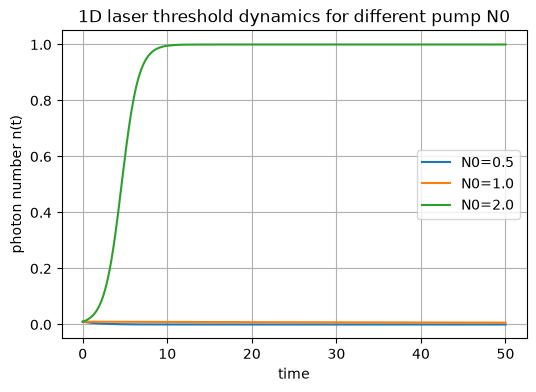

In [10]:
t = np.linspace(0.0, 50.0, 1000)
G, k, alpha = 1.0, 1.0, 1.0
n0 = 0.01

plt.figure(figsize=(6, 4))

for N0 in [0.5, 1.0, 2.0]:
    _, n = simulate_threshold(n0, t, G, N0, k, alpha)
    plt.plot(t, n, label=f"N0={N0}")

plt.xlabel("time")
plt.ylabel("photon number n(t)")
plt.title("1D laser threshold dynamics for different pump N0")
plt.legend()
plt.grid(True)
plt.show()

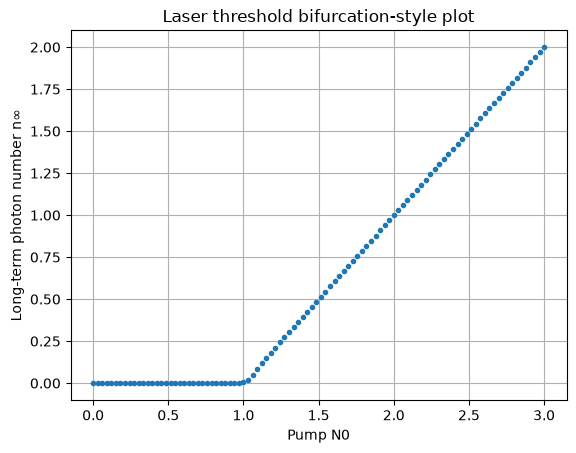

In [11]:
plot_threshold_bifurcation(G=1.0, k=1.0, alpha=1.0,
                           N0_min=0.0, N0_max=3.0,
                           num_points=100, t_max=50.0, n0=0.01)

## 2D Rate-Equation Laser Model

Next we consider a two-dimensional model for intensity \(I(t)\) and inversion \(N(t)\):

\[
\dot I = (N - 1) I,
\qquad
\dot N = \gamma(\mu - N - N I),
\]

where:
- \(I(t)\) is optical intensity,
- \(N(t)\) is population inversion,
- \(\mu\) is a dimensionless pump parameter,
- \(\gamma > 0\) is the ratio of time scales.

The equilibria are:
- Nonlasing: \((I^*, N^*) = (0, \mu)\), always exists.
- Lasing: \((I^*, N^*) = (\mu - 1, 1)\), exists when \(\mu > 1\).

The Jacobian is

\[
J(I, N) =
\begin{pmatrix}
N - 1 & I \\
-\gamma N & -\gamma(1 + I)
\end{pmatrix},
\]

and its eigenvalues determine the local stability of each equilibrium. [web:63]

In [12]:
gamma = 1.0

for mu in [0.5, 1.0, 1.5, 2.0]:
    eq_off, eq_on = equilibria_rate_equations(gamma, mu)
    J_off = jacobian_rate_equations(eq_off[0], eq_off[1], gamma)
    eig_off = np.linalg.eigvals(J_off)
    print(f"mu = {mu}")
    print("  nonlasing equilibrium:", eq_off)
    print("  eigenvalues (off):", eig_off)
    if eq_on is not None:
        J_on = jacobian_rate_equations(eq_on[0], eq_on[1], gamma)
        eig_on = np.linalg.eigvals(J_on)
        print("  lasing equilibrium:", eq_on)
        print("  eigenvalues (on):", eig_on)
    else:
        print("  lasing equilibrium: none (mu <= 1)")
    print()

mu = 0.5
  nonlasing equilibrium: [0.  0.5]
  eigenvalues (off): [-1. +0.j -0.5+0.j]
  lasing equilibrium: none (mu <= 1)

mu = 1.0
  nonlasing equilibrium: [0. 1.]
  eigenvalues (off): [-1.+0.j  0.+0.j]
  lasing equilibrium: none (mu <= 1)

mu = 1.5
  nonlasing equilibrium: [0.  1.5]
  eigenvalues (off): [-1. +0.j  0.5+0.j]
  lasing equilibrium: [0.5 1. ]
  eigenvalues (on): [-0.5+0.j -1. +0.j]

mu = 2.0
  nonlasing equilibrium: [0. 2.]
  eigenvalues (off): [-1.+0.j  1.+0.j]
  lasing equilibrium: [1. 1.]
  eigenvalues (on): [-1.+6.68896751e-09j -1.-6.68896751e-09j]



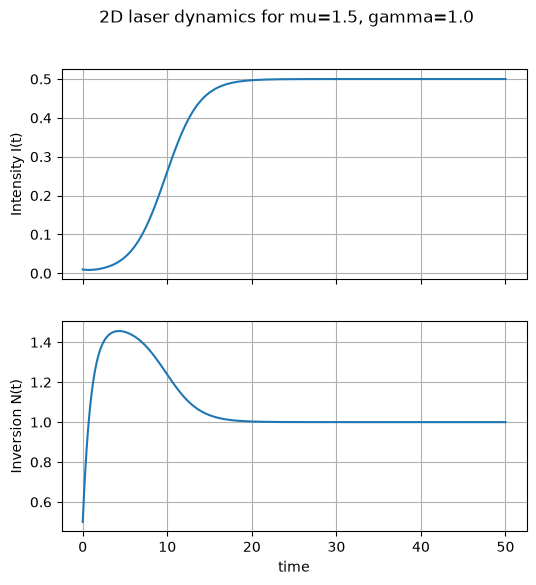

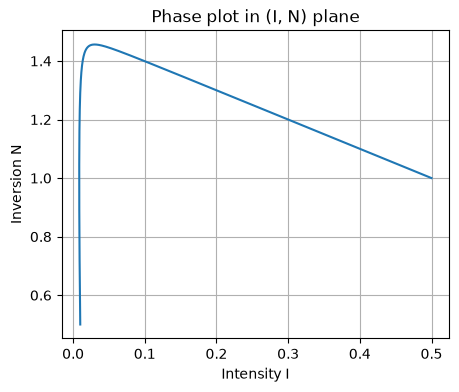

In [13]:
t = np.linspace(0.0, 50.0, 1000)
state0 = np.array([0.01, 0.5])  # small intensity, moderate N

mu = 1.5
gamma = 1.0

_, I, N = simulate_rate_equations(state0, t, gamma, mu)

fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
ax[0].plot(t, I)
ax[0].set_ylabel("Intensity I(t)")
ax[0].grid(True)

ax[1].plot(t, N)
ax[1].set_xlabel("time")
ax[1].set_ylabel("Inversion N(t)")
ax[1].grid(True)

fig.suptitle(f"2D laser dynamics for mu={mu}, gamma={gamma}")
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(I, N)
plt.xlabel("Intensity I")
plt.ylabel("Inversion N")
plt.title("Phase plot in (I, N) plane")
plt.grid(True)
plt.show()

## 3D Maxwell–Bloch Laser Model and Lorenz-Type Dynamics

For a more realistic laser, we consider a three-dimensional model (Maxwell–Bloch)
with variables:

- \(E(t)\): electric field amplitude,
- \(P(t)\): polarization,
- \(D(t)\): population inversion.

One common form is:

\[
\begin{aligned}
\dot E &= \kappa (P - E), \\
\dot P &= \gamma_1 (E D - P), \\
\dot D &= \gamma_2 \bigl(\lambda + 1 - D - \lambda E P\bigr),
\end{aligned}
\]

where \(\kappa, \gamma_1, \gamma_2 > 0\) are decay rates and \(\lambda\) is
a pump parameter. [web:84][web:143]

The nonlasing equilibrium is:

\[
E^* = 0, \quad P^* = 0, \quad D^* = \lambda + 1.
\]

By shifting the inversion to \(D' = D - (\lambda + 1)\) and rescaling, one can
transform this system into a Lorenz-type form, which is known to exhibit chaotic
dynamics for certain parameter values. [web:84][web:142]

In [14]:
kappa, gamma1, gamma2 = 1.0, 1.0, 1.0

for lam in [0.0, 0.5, 1.0, 1.5, 2.0]:
    fp = maxwell_bloch_fixed_points(lam)
    J = maxwell_bloch_jacobian(fp[0], fp[1], fp[2], kappa, gamma1, gamma2, lam)
    eigvals = np.linalg.eigvals(J)
    print(f"lambda = {lam}")
    print("  fixed point:", fp)
    print("  eigenvalues:", eigvals)
    print()

lambda = 0.0
  fixed point: [0. 0. 1.]
  eigenvalues: [ 0.+0.j -2.+0.j -1.+0.j]

lambda = 0.5
  fixed point: [0.  0.  1.5]
  eigenvalues: [ 0.22474487+0.j -2.22474487+0.j -1.        +0.j]

lambda = 1.0
  fixed point: [0. 0. 2.]
  eigenvalues: [ 0.41421356+0.j -2.41421356+0.j -1.        +0.j]

lambda = 1.5
  fixed point: [0.  0.  2.5]
  eigenvalues: [ 0.58113883+0.j -2.58113883+0.j -1.        +0.j]

lambda = 2.0
  fixed point: [0. 0. 3.]
  eigenvalues: [ 0.73205081+0.j -2.73205081+0.j -1.        +0.j]



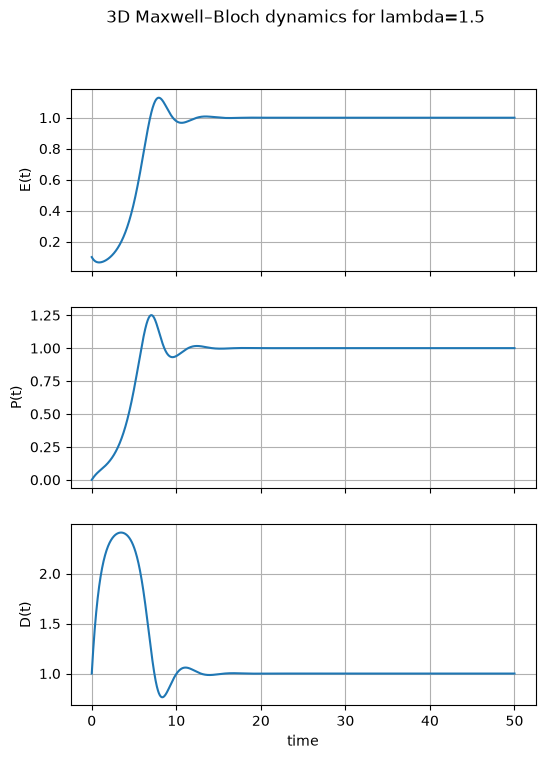

In [15]:
from scipy.integrate import odeint

t = np.linspace(0.0, 50.0, 2000)
state0 = np.array([0.1, 0.0, 1.0])  # small field, initial polarization, inversion

lam = 1.5
traj = odeint(
    lambda s, t_: maxwell_bloch_rhs(s, t_, kappa, gamma1, gamma2, lam),
    state0, t
)
E = traj[:, 0]
P = traj[:, 1]
D = traj[:, 2]

fig, ax = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
ax[0].plot(t, E); ax[0].set_ylabel("E(t)"); ax[0].grid(True)
ax[1].plot(t, P); ax[1].set_ylabel("P(t)"); ax[1].grid(True)
ax[2].plot(t, D); ax[2].set_xlabel("time"); ax[2].set_ylabel("D(t)"); ax[2].grid(True)
fig.suptitle(f"3D Maxwell–Bloch dynamics for lambda={lam}")
plt.show()